Here I include all of the electrodes. I want to see if the result is better without using the delay

In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path
#from sklearn.cross_decomposition import CCA
from mvlearn.embed import CCA
from scipy.stats import pearsonr 
from scipy import stats
from typing import List, Tuple, Optional
import numpy as np


###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

OUT_TRIALS  = Path("trial_level_cca_fixedlag.csv")
OUT_SUBJECT = Path("subject_best_lag.csv")

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SHIFTS = np.arange(-100, 101)      # ±1 s at 100 Hz → samples
WIN_OFFSET1 = 200                  # discard first 200 ms
WIN_OFFSET2 = 110                  # discard last 110 ms

###############################################################################
# Helper functions
###############################################################################

def normalise_eeg(x: np.ndarray) -> np.ndarray:
    """Centre each channel and scale so Σ x² = 1 over time×channels."""
    x = x - x.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(x**2))
    return x / scale


def cca_corr(eeg: np.ndarray, pupil: np.ndarray) -> float:
    """Canonical correlation (single component)."""
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(eeg, pupil)
    u, v = cca.transform(eeg, pupil)
    return float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])

In [2]:
def load_all_trials(
        sub: int,
        eeg_root: Path = EEG_ROOT,
        pupil_root: Path = PUPIL_ROOT,
        min_len: int = 40,
        max_len_diff: int = 30,
) -> list[tuple[np.ndarray, np.ndarray, dict]]:
    """
    Load *all* valid EEG-pupil trial pairs for one subject.

    Parameters
    ----------
    sub : int
        Numeric subject ID (e.g. 42).
    eeg_root, pupil_root : Path
        Roots of the pre-processed EEG and pupil folders.
    min_len : int
        Minimum number of samples a pupil trace must have to be accepted.
    max_len_diff : int
        Reject trial if |len(pupil)-len(eeg)| exceeds this.
    Returns
    -------
    trials : list of (eeg, pupil_z, meta)
        * eeg        - (T × n_channels) float64, already centred/scaled
        * pupil_z    - (T × 1) float64, per-trial z-scored
        * meta       - dict with subject/condition/load/epoch
    """
    trials = []
    sub_tag = f"sub-{sub:03d}"
    eeg_sub  = eeg_root   / sub_tag
    pupil_sub = pupil_root / sub_tag

    if not eeg_sub.exists():
        print(f"{sub_tag}: EEG folder missing - skipped")
        return trials

    # iterate condition (“control” / “memory”) and load (“05” / “09” / “13”)
    for cond_path in sorted(eeg_sub.iterdir()):
        if not cond_path.is_dir():
            continue
        for load_path in sorted(cond_path.iterdir()):
            if not load_path.is_dir():
                continue

            # matching pupil directory
            pupil_path = pupil_sub / cond_path.name / load_path.name
            if not pupil_path.exists():
                continue

            eeg_epochs   = sorted(load_path.glob("trial_*.csv"))
            pupil_epochs = sorted(pupil_path.glob("trial_*.csv"))
            common = {f.name for f in eeg_epochs} & {f.name for f in pupil_epochs}
            if not common:
                continue

            for fname in sorted(common):
                eeg_df = pd.read_csv(load_path / fname, comment="#", index_col=0)
                pupil_df = pd.read_csv(pupil_path / fname, comment="#", skiprows=1,
                                       names=["time", "diameter_z"], index_col=0)

                eeg   = eeg_df.values.astype(float)
                pupil = pupil_df["diameter_z"].values.astype(float)

                # basic validity checks
                if len(pupil) < min_len or abs(len(pupil) - len(eeg)) > max_len_diff:
                    continue

                # normalise signals ----------------------------------------
                #eeg_norm = normalise_eeg(eeg)           # your helper from before
                #pupil_z  = ((pupil - pupil.mean()) / pupil.std(ddof=0))

                # same number of samples
                T = min(len(eeg), len(pupil))
                eeg = eeg[0:T, :]  # (T × n_channels)
                pupil  = pupil[0:T].reshape(-1, 1)

                meta = {
                    "subject":   sub_tag,
                    "condition": cond_path.name,
                    "load":      int(load_path.name),
                    "epoch":     fname
                }
                trials.append((eeg, pupil, meta))

    return trials

from typing import List, Tuple
import numpy as np

def split_trials_by_condition(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        memory_label: str = "memory",
        control_label: str = "control"
) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into memory-condition and control-condition sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'condition'.
    memory_label : str
        The value of meta['condition'] that marks a memory trial.
    control_label : str
        The value of meta['condition'] that marks a control trial.

    Returns
    -------
    memory_trials  : list[tuple]
    control_trials : list[tuple]
    """
    memory_trials  = []
    control_trials = []

    for eeg, pupil, meta in trials:
        cond = meta.get("condition", "").lower()
        if cond == memory_label:
            memory_trials.append((eeg, pupil, meta))
        elif cond == control_label:
            control_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown condition label: {cond}")

    return memory_trials, control_trials
    
def split_trials_by_load(trials: List[Tuple[np.ndarray, np.ndarray, dict]]
                         ) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into 05, 09 and 13 load sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'load'.

    Returns
    -------
    load_05_trials  : list[tuple]
    load_09_trials  : list[tuple]
    load_13_trials  : list[tuple]
    """
    load_05_trials = []
    load_09_trials = []
    load_13_trials = []

    for eeg, pupil, meta in trials:
        load = meta.get("load")
        if load == 5:
            load_05_trials.append((eeg, pupil, meta))
        elif load == 9:
            load_09_trials.append((eeg, pupil, meta))
        elif load == 13:
            load_13_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown load label: {load}")

    return load_05_trials, load_09_trials, load_13_trials

In [3]:
from typing import List, Tuple, Optional, Dict
def concat_trials(
    trials: List[Tuple[np.ndarray, np.ndarray, dict]],
    shift: int = 0,  # samples; positive = EEG delayed (EEG after pupil)
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate trials for CCA without circular wrap.

    Returns
    -------
    X : ndarray, shape (Σ T_eff, n_channels)   # EEG
    Y : ndarray, shape (Σ T_eff, 1)            # pupil
    """
    X_blocks, Y_blocks = [], []

    for eeg, pupil_z, _ in trials:
        # Ensure 1D/2D shapes: EEG (T, C), pupil (T, 1)
        if eeg.ndim == 1:
            eeg = eeg[:, None]
        if pupil_z.ndim == 1:
            pupil_z = pupil_z[:, None]

        T = min(len(eeg), len(pupil_z))
        if T == 0:
            print("Warning: zero-length trial encountered - skipped")
            continue

        # Optional common window first (keeps boundaries away)
        start = WIN_OFFSET1
        stop  = T - WIN_OFFSET2
        if stop <= start:
            print("Warning: collapsed window after trimming - skipped")
            continue  # window collapsed; skip this trial

        eeg_w   = eeg[start:stop]
        pupil_w = pupil_z[start:stop]
        Tw = len(eeg_w)

        # Apply lag by asymmetric trimming (no roll, no wrap)
        # Positive shift => EEG delayed => drop 'shift' from EEG start and pupil end
        # Negative shift => EEG advanced => drop '-shift' from pupil start and EEG end
        if shift >= 0:
            if Tw <= shift:
                continue  # nothing left after lag
            eeg_seg   = eeg_w[shift:]             # drop early EEG
            pupil_seg = pupil_w[:Tw - shift]      # drop late pupil
        else:
            s = -shift
            if Tw <= s:
                continue
            eeg_seg   = eeg_w[:Tw - s]            # drop late EEG
            pupil_seg = pupil_w[s:]               # drop early pupil
    
        eeg_seg = normalise_eeg(eeg_seg)           # your helper from before
        pupil_seg = ((pupil_seg - pupil_seg.mean()) / pupil_seg.std(ddof=0))

        # Shapes now match
        X_blocks.append(eeg_seg)
        Y_blocks.append(pupil_seg)

    if not X_blocks:
        print("Warning: no valid trials after concatenation - returning empty arrays")
        return np.empty((0, trials[0][0].shape[-1])), np.empty((0, 1))

    X = np.vstack(X_blocks)
    Y = np.vstack(Y_blocks)
    return X, Y

def iterate_trials(trials, shift):
    """
    Yield (eeg_aligned, pupil_aligned, meta) one by one, with no circular wrap.

    Conventions
    -----------
    - `shift` in samples, along time axis (axis=0).
    - shift >= 0  → EEG delayed  → drop early EEG, drop late pupil
    - shift <  0  → EEG advanced → drop late EEG, drop early pupil
    """
    for eeg, pupil_z, meta in trials:
        # Window first
        T = min(len(eeg), len(pupil_z))
        start = WIN_OFFSET1
        stop  = T - 50
        if stop <= start:
            print("Warning: collapsed window after trimming - skipped")
            continue  # window collapsed; skip this trial

        eeg_w   = eeg[start:stop]
        pupil_w = pupil_z[start:stop]

        # Ensure both have time along axis 0 and share the same window length
        Tw = len(eeg_w)
        
        if Tw == 0: continue

        if shift >= 0: # EEG delayed: drop early EEG, drop late pupil
            eeg_out   = eeg_w[shift:]           # works for 1D or 2D (time on axis 0)
            pupil_out = pupil_w[:Tw - shift]
        else:
            s = -shift # EEG advanced: drop late EEG, drop early pupil
            
            eeg_out   = eeg_w[:Tw - s]
            pupil_out = pupil_w[s:]

        eeg_out = normalise_eeg(eeg_out)
        pupil_out = ((pupil_out - pupil_out.mean()) / pupil_out.std(ddof=0))

        yield eeg_out, pupil_out, meta.copy()

In [4]:
# ---------- HELPERS --------------------------------------------
import matplotlib.pyplot as plt
def find_weight_file(subj: int,
                     base_dir: Path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\cca_weights_slow")
                     ) -> Path:
    """
    Find the CSV for given condition ('ctrl' or 'mem') for the chosen subject.
    If lag_ms is provided, match exactly. Otherwise, take any that matches.
    """
    subj_str = f"{subj:03d}"
    subj_glob = f"sub-{subj_str}_eeg_weights_mem_*.csv"
    candidates = list((base_dir).glob(subj_glob))
    if not candidates:
        return None
    if len(candidates) > 1:
        return None  # ambiguous
    return candidates[0]

def load_weights(subj: int):
    csv_path = find_weight_file(subj)
    if csv_path is None or not csv_path.exists():
        return None, None
    df = pd.read_csv(csv_path)
    ch_names = df['channel'].tolist()
    weights  = df['weight'].to_numpy()
    return ch_names, weights

Subject 033
Subject 034
Subject 035
Subject 036
Subject 038
Subject 039
Subject 040
Subject 041
Subject 042
Subject 043
Subject 044
Subject 045
Subject 046
Subject 047
Subject 048
Subject 049
Subject 050
Subject 051
Subject 052
Subject 054
Subject 055
Subject 056
Subject 057
Subject 058
Subject 059
Subject 060
Subject 062
Subject 063
Subject 064
Subject 065
Subject 067
Subject 068
Subject 069
Subject 070
Subject 071
Subject 072
Subject 073
Subject 074
Subject 075
Subject 076
Subject 077
Subject 079
Subject 080
Subject 081
Subject 082
Subject 083
Subject 085
Subject 086
Subject 087
Subject 088
Subject 089
Subject 091
Subject 092
Subject 093
Subject 095
Subject 097
Subject 098
Finished - saved per-trial correlations with plain CCA.
Finished - saved per-trial and digit correlations with plain CCA.


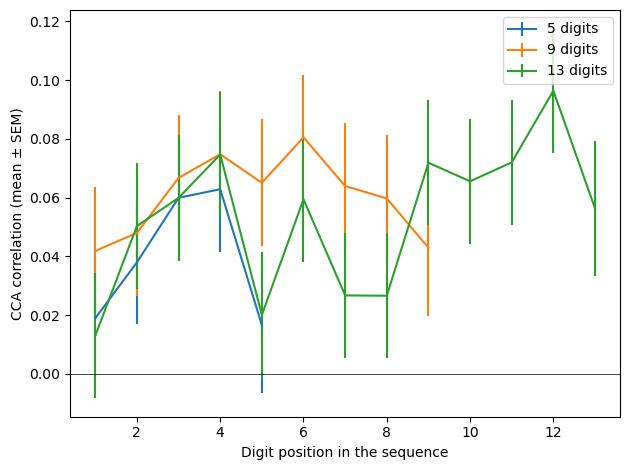

In [6]:
DIG_LEN = 200
data = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\subject_level_cca_slow.csv")
best_shift_by_sub = data.groupby("subject")["lag_ms"].agg(lambda x: x.value_counts().index[0]).to_dict()
rows_trials = []
all_rows = []
win = slice(WIN_OFFSET1, -WIN_OFFSET2)

for subj in SUBJECTS:
    print(f"Subject {subj:03d}")
    #best_shift = best_shift_by_sub.get(subj, 0) // 10  # convert ms to samples
    best_shift  = int(0)
    trials_memory, trials_control = split_trials_by_condition(load_all_trials(subj))
    channels_w,  weights  = load_weights(subj)

    if channels_w is None or weights is None:
        print(f"Missing or ambiguous weights for subject {subj:03d}, skipping subject.")
        continue
    
    for eeg_s, pupil_s, meta in iterate_trials(trials_memory, best_shift):
        n_digits = meta['load']
        
        channel_out = 5  # F1 channel index
        eeg_s_no_ch = np.delete(eeg_s, channel_out, axis=1)
        weights_no_ch = np.delete(weights, channel_out)
        

        cv_eeg = np.dot(eeg_s, weights)
        cv_pupil = pupil_s.ravel()
        cv_eeg_no_ch = np.dot(eeg_s_no_ch, weights_no_ch)

        for d in range(n_digits):
            w = slice(d * DIG_LEN, (d + 1) * DIG_LEN)
            x, y = cv_eeg[w], cv_pupil[w]
            x_no_ch = cv_eeg_no_ch[w]
            
            if x.size == 0 or y.size == 0:
                print("Empty slice:", meta['subject'], meta['epoch'], d)
                continue

            if not np.isfinite(x).all() or not np.isfinite(y).all():
                print("Non-finite values:", meta['subject'], meta['epoch'], d, "→", np.sum(~np.isfinite(x)), "bad in X;", np.sum(~np.isfinite(y)), "bad in Y")
                continue

            if np.std(x) == 0 or np.std(y) == 0:
                print("Const window:", meta['subject'], meta['epoch'], d, np.std(x), np.std(y))
                continue

            r = pearsonr(x, y)[0]
            #r = np.corrcoef(x, y)[0, 1]


            rows_trials.append({
                'subject': meta['subject'],
                'condition': meta['condition'],
                'load': meta['load'],
                'epoch': meta['epoch'],
                'lag_ms': best_shift * 10,  # convert samples to ms
                'digit_pos': d + 1,  # 1-based digit index
                'pupil': float(np.mean(y)),  # mean pupil size in this digit
                'eeg_channels': np.mean(eeg_s[w, :], axis=0),
                'F1': float(np.mean(eeg_s[w, channel_out])),  # mean EEG, F1 signal in this digit
                'eeg_cca': float(np.mean(x)),  # mean CCA component in this digit
                'eeg_cca_no_ch': float(np.mean(x_no_ch)),  # mean CCA without F1
                'r': float(r),  # convert to plain float for JSON-ability
            })

        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)

df_sameW = pd.DataFrame(rows_trials)
grand = (df_sameW.query("condition == 'memory'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

pd.DataFrame(all_rows).to_csv("mem_trial_level_cca_slow_noLag.csv", index=False)
print("Finished - saved per-trial correlations with plain CCA.")

pd.DataFrame(rows_trials).to_csv("mem_digit_level_cca_slow_noLag.csv", index=False)
print("Finished - saved per-trial and digit correlations with plain CCA.")

In [1]:
%matplotlib qt
# %matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

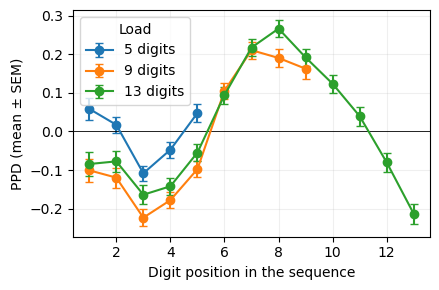

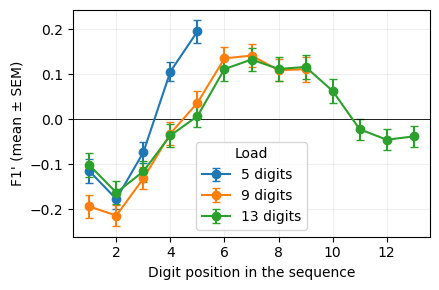

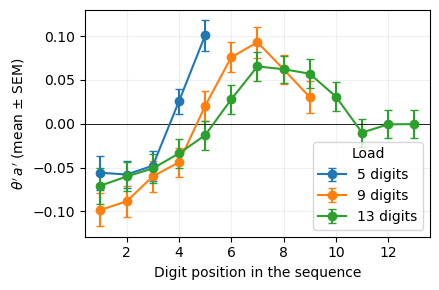

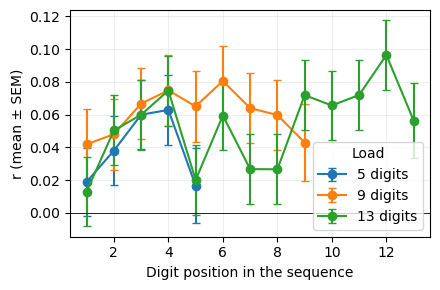

In [7]:
import pandas as pd
def parse_vec(s: str) -> np.ndarray:
    return np.fromstring(s.strip('[]'), sep=' ')

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow_noLag_noLag.csv")
idx = 4  # the channel you want

mem['eeg_channels'] = mem['eeg_channels'].apply(parse_vec)
mem['eeg_sel'] = mem['eeg_channels'].apply(lambda a: a[idx])

# Aggregate (mean ± SEM) per load × digit_pos, memory only
agg = {"mean": "mean", "sem": "sem"}
grand = {
    "pupil": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['pupil'].agg(['mean','sem']).reset_index()),
    "F1'": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['eeg_sel'].agg(['mean','sem']).reset_index()),
    "eeg_cca_no_ch": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['eeg_cca_no_ch'].agg(['mean','sem']).reset_index()),
    "r": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['r'].agg(['mean','sem']).reset_index()),
}

ylabels = {
    "F1'": "F1' (mean ± SEM)",
    "pupil": "PPD (mean ± SEM)",
    "eeg_cca_no_ch": r"$\theta' \, a'$ (mean ± SEM)",
    "r": "r (mean ± SEM)",
}

loads = [5, 9, 13]

for name, df in grand.items():
    plt.figure(figsize=(4.5,3))
    for L in loads:
        sub = df[df["load"] == L].copy()
        # ensure numeric and sorted x
        sub["digit_pos"] = pd.to_numeric(sub["digit_pos"], errors="coerce")
        sub = sub.dropna(subset=["digit_pos"]).sort_values("digit_pos")
        plt.errorbar(sub["digit_pos"], sub["mean"], yerr=sub["sem"], marker="o", linestyle="-", capsize=3, label=f"{L} digits")
    plt.axhline(0, lw=.6, color="k")
    plt.xlabel("Digit position in the sequence")
    plt.ylabel(ylabels.get(name, f"{name} (mean ± SEM)"))
    #plt.title(f"Grand {name} vs. digit position (memory)")
    plt.legend(title="Load")
    plt.grid(alpha=.2)
    plt.tight_layout()
    # plt.show()  # optional in notebooks


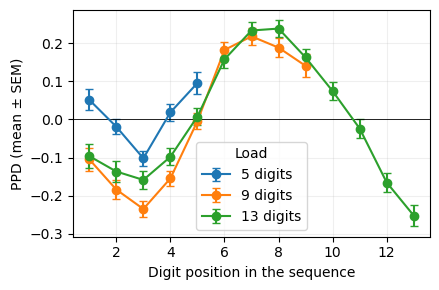

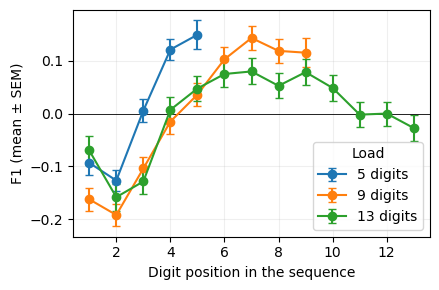

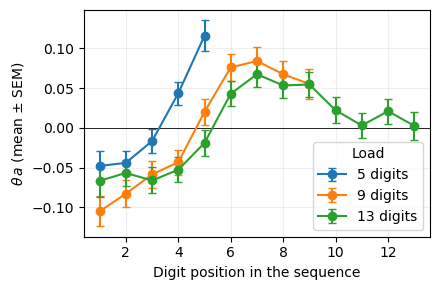

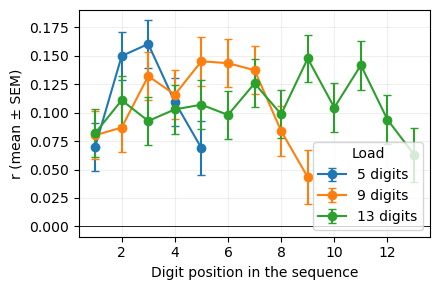

In [7]:
import pandas as pd

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")

# Aggregate (mean ± SEM) per load × digit_pos, memory only
agg = {"mean": "mean", "sem": "sem"}
grand = {
    "pupil": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['pupil'].agg(['mean','sem']).reset_index()),
    "F1": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['F1'].agg(['mean','sem']).reset_index()),
    "eeg_cca": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['eeg_cca'].agg(['mean','sem']).reset_index()),
    "r": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['r'].agg(['mean','sem']).reset_index()),
}

ylabels = {
    "F1": "F1 (mean ± SEM)",
    "pupil": "PPD (mean ± SEM)",
    "eeg_cca": r"$\theta \, a$ (mean ± SEM)",
    "r": "r (mean ± SEM)",
}

loads = [5, 9, 13]

for name, df in grand.items():
    plt.figure(figsize=(4.5,3))
    for L in loads:
        sub = df[df["load"] == L].copy()
        # ensure numeric and sorted x
        sub["digit_pos"] = pd.to_numeric(sub["digit_pos"], errors="coerce")
        sub = sub.dropna(subset=["digit_pos"]).sort_values("digit_pos")
        plt.errorbar(sub["digit_pos"], sub["mean"], yerr=sub["sem"], marker="o", linestyle="-", capsize=3, label=f"{L} digits")
    plt.axhline(0, lw=.6, color="k")
    plt.xlabel("Digit position in the sequence")
    plt.ylabel(ylabels.get(name, f"{name} (mean ± SEM)"))
    #plt.title(f"Grand {name} vs. digit position (memory)")
    plt.legend(title="Load")
    plt.grid(alpha=.2)
    plt.tight_layout()
    # plt.show()  # optional in notebooks


In [3]:
import pandas as pd, numpy as np, statsmodels.api as sm, statsmodels.formula.api as smf

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

def parse_vec(s: str) -> np.ndarray:
    # if already an array/list, return as-is
    if isinstance(s, (np.ndarray, list, tuple)):
        return np.asarray(s, dtype=float)
    # if stored as string like "[ 1.2  3.4 ... ]"
    return np.fromstring(str(s).strip('[]'), sep=' ')

# 1) Load raw trial-level data
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow_noLag.csv")

# Parse vector column
mem['eeg_channels'] = mem['eeg_channels'].apply(parse_vec)

# Expand to 17 named columns (assumes the order in the vector matches FRONTAL_MIDLINE)
arr = np.vstack(mem['eeg_channels'].to_numpy())
assert arr.shape[1] == 17, f"Expected 17 channels, got {arr.shape[1]}"
mem[FRONTAL_MIDLINE] = arr

# Handy single-channel selection if you still want it
idx = 4  # e.g., 'F1' index in FRONTAL_MIDLINE
mem['eeg_sel']  = arr[:, idx]
mem['eeg_mean'] = arr.mean(axis=1)

# Basic cleaning / types
mem["subject"]   = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")

num_cols_to_force = ["pupil","eeg_sel","eeg_cca_no_ch","r","F1","eeg_mean","eeg_cca"] + FRONTAL_MIDLINE
for v in num_cols_to_force:
    if v in mem.columns:
        mem[v] = pd.to_numeric(mem[v], errors="coerce")

mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","eeg_cca_no_ch"])

# 2) Demean within (subject × epoch)
grp = mem.groupby(["subject","epoch"], sort=False)

mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["eeg_cca_wt"]   = mem["eeg_cca"]   - grp["eeg_cca"].transform("mean") if "eeg_cca" in mem else np.nan
mem["eeg_mean_wt"]  = mem["eeg_mean"]  - grp["eeg_mean"].transform("mean")
mem["r_wt"]         = mem["r"]         - grp["r"].transform("mean")       if "r" in mem else np.nan

# Demean each of the 17 channels
ch_wt_names = []
for ch in FRONTAL_MIDLINE:
    wt_name = f"{ch}_wt"
    mem[wt_name] = mem[ch] - grp[ch].transform("mean")
    ch_wt_names.append(wt_name)

# Collect predictors to z-score (optional, improves comparability)
v_wts = ["digit_pos_wt","pupil_wt","eeg_mean_wt"] + ch_wt_names
if "eeg_cca_wt" in mem:
    v_wts.append("eeg_cca_wt")
if "r_wt" in mem and mem["r_wt"].notna().any():
    v_wts.append("r_wt")

# Optional: z-score AFTER demeaning
for c in v_wts:
    if c in mem:
        mu, sd = mem[c].mean(), mem[c].std(ddof=1)
        if pd.notna(sd) and sd > 0:
            mem[c] = (mem[c] - mu) / sd

# 3) OLS with subject fixed effects and cluster-robust SEs BY SUBJECT
# (Your comment said "by subject", so we’ll actually cluster on subject, not subtrial.)
predictors =  ch_wt_names + ["pupil_wt", "r"]
predictors = [p for p in predictors if p in mem.columns]  # keep only existing ones
formula = "digit_pos_wt ~ " + " + ".join(predictors) + " + C(subject)"

m_trial = smf.ols(formula, data=mem).fit(
    cov_type="cluster",
    cov_kwds={"groups": mem["subject"]}  # cluster by subject
)

print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

# 4) Unique contribution of EEG at trial-level: partial R² (EEG | pupil,eeg_sel)
predictors_red = [p for p in ch_wt_names if p in mem.columns]  # keep only existing ones
formula = "digit_pos_wt ~ " + " + ".join(predictors_red) + " + C(subject)"
m_red = smf.ols(formula, data=mem).fit(
    cov_type="cluster",
    cov_kwds={"groups": mem["subject"]}  # cluster by subject
)
SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_trial.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) at trial-level =", partial_R2_eeg)


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 75, but rank is 19
  warnings.warn('covariance of constraints does not have full '


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              9.135e-05   6.64e-05      1.375      0.169   -3.89e-05       0.000
C(subject)[T.sub-034]    -0.0010      0.001     -1.375      0.169      -0.002       0.000
C(subject)[T.sub-035]     0.0016      0.001      1.375      0.169      -0.001       0.004
C(subject)[T.sub-036]    -0.0008      0.001     -1.375      0.169      -0.002       0.000
C(subject)[T.sub-038]    -0.0011      0.001     -1.375      0.169      -0.003       0.000
C(subject)[T.sub-039]    -0.0008      0.001     -1.375      0.169      -0.002       0.000
C(subject)[T.sub-040]    -0.0002      0.000     -1.375      0.169      -0.000    7.17e-05
C(subject)[T.sub-041]    -0.0009      0.001     -1.375      0.169      -0.002       0.000
C(subject)[T.sub-042]    -0.0006      0.000     -1.375      0.169      -0.002       0.000
C(subject)

In [50]:
# ---- Subject-specific orthogonalization wrt subject-specific w ----

def align_subject_weights(subj, channel_order):
    """Return a length-17 weight vector aligned to channel_order for this subject, or None."""
    ch_names, w = load_weights(subj)  # your function from earlier
    if ch_names is None or w is None:
        return None
    w_map = dict(zip(ch_names, w))
    try:
        w_aligned = np.array([w_map[ch] for ch in channel_order], dtype=float)
    except KeyError:
        # missing channels in this subject's weight file
        return None
    if not np.isfinite(w_aligned).all() or w_aligned.size != len(channel_order):
        return None
    return w_aligned

# Pre-create output columns
orth_names = [f'orth_{i}' for i in range(1, 17)]
mem['eeg_cca_wt_proj'] = np.nan
for name in orth_names:
    mem[name] = np.nan

# Demeaned channel matrix columns (17)
wt_cols = [f"{ch}_wt" for ch in FRONTAL_MIDLINE]

# Process per subject
for subj, g in mem.groupby('subject'):
    sub_int = int(subj[5:7])
    w = align_subject_weights(sub_int, FRONTAL_MIDLINE)
    if w is None:
        # skip this subject if no usable weights
        continue

    # Normalize w (direction only)
    nrm = np.linalg.norm(w)
    if nrm == 0 or not np.isfinite(nrm):
        continue
    w_unit = w / nrm

    # Build orthonormal basis with first vector = w_unit (QR trick)
    B = np.eye(17)
    B[:, 0] = w_unit
    Q, _ = np.linalg.qr(B)  # Q: 17x17, orthonormal columns, Q[:,0] ~ w_unit

    # Rotate the demeaned channels for this subject
    X_wt = g[wt_cols].to_numpy()          # shape (n_subj_rows, 17)
    Z = X_wt @ Q                          # same shape

    # Fill outputs
    mem.loc[g.index, 'eeg_cca_wt_proj'] = Z[:, 0]  # projection along w
    for i, name in enumerate(orth_names, start=1):
        mem.loc[g.index, name] = Z[:, i]

# TO CHECK FOR MULTICOLLINEARITY within each subject
for subj, g in mem.groupby("subject"):
    y = g["eeg_cca_wt"].to_numpy()
    X = g[[f"{c}_wt" for c in FRONTAL_MIDLINE]].to_numpy()
    X_orth = g[[f"orth_{i}" for i in range(1, 17)]].to_numpy()
    if len(g) >= len(FRONTAL_MIDLINE):  # enough rows
        beta_orth, *_ = np.linalg.lstsq(X_orth, y, rcond=None)
        resid_orth = y - X_orth @ beta_orth
        r2_orth = 1 - (resid_orth @ resid_orth) / ( (y - y.mean()) @ (y - y.mean()) )
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ beta
        r2 = 1 - (resid @ resid) / ( (y - y.mean()) @ (y - y.mean()) )
        print(subj, "R² =", r2, "(original)", r2_orth, "(orthogonalized)")

# TO CHECK MULTICOLLINEARITY OVER ALL DATA (it isnt multicollinear because there is different weights per subject)

CH = [f"{c}_wt" for c in FRONTAL_MIDLINE]  # use the demeaned versions you modeled with
y  = mem["eeg_cca_wt"].to_numpy()
X  = mem[CH].to_numpy()

# OLS of eeg_cca_wt on channels (no intercept; both are demeaned)
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
resid = y - X @ beta
r2 = 1 - (resid @ resid) / ( (y - y.mean()) @ (y - y.mean()) )

print("R^2 (eeg_cca_wt ~ channels_wt):", r2)
print("Residual L2 norm:", np.linalg.norm(resid))


sub-033 R² = 1.0 (original) 0.6674961587888906 (orthogonalized)
sub-034 R² = 1.0 (original) 0.650474457026506 (orthogonalized)
sub-035 R² = 1.0 (original) 0.8224641431392783 (orthogonalized)
sub-036 R² = 1.0 (original) 0.5785988893971226 (orthogonalized)
sub-038 R² = 1.0 (original) 0.6224410204841923 (orthogonalized)
sub-039 R² = 1.0 (original) 0.4526295699788069 (orthogonalized)
sub-040 R² = 1.0 (original) 0.6424887915428208 (orthogonalized)
sub-041 R² = 1.0 (original) 0.6241661530980567 (orthogonalized)
sub-042 R² = 1.0 (original) 0.6298086737871943 (orthogonalized)
sub-043 R² = 1.0 (original) 0.6585330659401386 (orthogonalized)
sub-044 R² = 1.0 (original) 0.5533855083431534 (orthogonalized)
sub-045 R² = 1.0 (original) 0.5042007129978889 (orthogonalized)
sub-046 R² = 1.0 (original) 0.6494918491058443 (orthogonalized)
sub-047 R² = 1.0 (original) 0.4748980227369818 (orthogonalized)
sub-048 R² = 1.0 (original) 0.5353251077141061 (orthogonalized)
sub-049 R² = 1.0 (original) 0.64234982207

In [ ]:
# 3) OLS with subject fixed effects and cluster-robust SEs BY SUBJECT
# (Your comment said "by subject", so we’ll actually cluster on subject, not subtrial.)
predictors = ["eeg_cca_wt_proj"] + orth_names
predictors = [p for p in predictors if p in mem.columns]  # keep only existing ones
formula = "digit_pos_wt ~ " + " + ".join(predictors) + " + C(subject)"

m_trial = smf.ols(formula, data=mem).fit(
    cov_type="cluster",
    cov_kwds={"groups": mem["subject"]}  # cluster by subject
)

print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

# 4) Unique contribution of EEG at trial-level: partial R² (EEG | pupil,eeg_sel)
predictors_red = [p for p in orth_names if p in mem.columns]  # keep only existing ones
formula = "digit_pos_wt ~ " + " + ".join(predictors_red) + " + C(subject)"
m_red = smf.ols(formula, data=mem).fit(
    cov_type="cluster",
    cov_kwds={"groups": mem["subject"]}  # cluster by subject
)
SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_trial.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) at trial-level =", partial_R2_eeg)

In [ ]:
# 3) OLS with subject fixed effects and cluster-robust SEs by subject
mem["subtrial"] = mem["subject"].astype(str) + "|" + mem["epoch"].astype(str)
m_trial = smf.ols("digit_pos_wt ~ pupil_wt + eeg_cca_wt + eeg_mean_wt + C(subject)", data=mem) \
             .fit(cov_type="cluster", cov_kwds={"groups": mem["subtrial"]})


print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

# 4) Unique contribution of EEG at trial-level: partial R² (EEG | pupil,eeg_sel)
m_red = smf.ols("digit_pos_wt ~ pupil_wt + eeg_mean_wt + C(subject)", data=mem).fit()
SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_trial.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) at trial-level =", partial_R2_eeg)


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 3
  warnings.warn('covariance of constraints does not have full '


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -3.464e-14   3.66e-15     -9.476      0.000   -4.18e-14   -2.75e-14
C(subject)[T.sub-034]  3.468e-14   3.67e-15      9.443      0.000    2.75e-14    4.19e-14
C(subject)[T.sub-035]  3.474e-14   3.69e-15      9.409      0.000    2.75e-14     4.2e-14
C(subject)[T.sub-036]  3.458e-14   3.68e-15      9.391      0.000    2.74e-14    4.18e-14
C(subject)[T.sub-038]  3.475e-14   3.75e-15      9.266      0.000    2.74e-14    4.21e-14
C(subject)[T.sub-039]  3.499e-14   3.69e-15      9.471      0.000    2.77e-14    4.22e-14
C(subject)[T.sub-040]  3.508e-14   3.71e-15      9.455      0.000    2.78e-14    4.24e-14
C(subject)[T.sub-041]  3.511e-14   3.66e-15      9.607      0.000     2.8e-14    4.23e-14
C(subject)[T.sub-042]  3.514e-14   3.67e-15      9.577      0.000     2.8e-14    4.23e-14
C(subject)

In [ ]:

m_trial = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + C(subject)", data=mem) \
             .fit(cov_type="cluster", cov_kwds={"groups": mem["subtrial"]})


print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -9.355e-14   9.63e-15     -9.717      0.000   -1.12e-13   -7.47e-14
C(subject)[T.sub-034]  9.343e-14   9.63e-15      9.700      0.000    7.46e-14    1.12e-13
C(subject)[T.sub-035]  9.362e-14    9.7e-15      9.650      0.000    7.46e-14    1.13e-13
C(subject)[T.sub-036]  9.329e-14   9.66e-15      9.652      0.000    7.43e-14    1.12e-13
C(subject)[T.sub-038]  9.405e-14   9.67e-15      9.728      0.000    7.51e-14    1.13e-13
C(subject)[T.sub-039]  9.445e-14   9.66e-15      9.782      0.000    7.55e-14    1.13e-13
C(subject)[T.sub-040]  9.517e-14   9.66e-15      9.853      0.000    7.62e-14    1.14e-13
C(subject)[T.sub-041]  9.497e-14   9.76e-15      9.728      0.000    7.58e-14    1.14e-13
C(subject)[T.sub-042]  9.461e-14   9.63e-15      9.820      0.000    7.57e-14    1.13e-13
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 2
  warnings.warn('covariance of constraints does not have full '


## CLASSIFICATION INTO AREAS WITH CV AND MULTINOMIAL REGRESSION

In [44]:
bin_map = {
    "early": {1, 2, 3},
    "mid":   {7, 8, 9},
    "late":  {11, 12, 13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})
#binned_mem = binned_mem[binned_mem["load"] == 13]

In [ ]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned_mem.dropna(subset=["subject","bin3","F1_wt","pupil_wt","eeg_cca_wt","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "EEG+pupil":     ["pupil_wt"] + ch_wt_names,
    "EEG+pupil+r+eeg_cca":   ["pupil_wt", "r_wt", "eeg_cca_wt"] + ch_wt_names,
    "EEG+pupil+r":   ["pupil_wt", "r_wt"] + ch_wt_names,
    "EEGorth + pupil + r":      ["pupil_wt", "eeg_cca_wt_proj", "r_wt"] + orth_names,
    "EEG":       ch_wt_names,
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_cca_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_cca_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare EEG+pupil+r vs EEG+pupil
show_details("EEG+pupil+r")
show_details("EEG+pupil")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
              model                                                                                                                                                               features  accuracy  macro_f1
EEG+pupil+r+eeg_cca               pupil_wt, r_wt, eeg_cca_wt, AFz_wt, AF3_wt, AF4_wt, Fz_wt, F1_wt, F2_wt, F3_wt, F4_wt, FC3_wt, FC1_wt, FC2_wt, FC4_wt, Cz_wt, C3_wt, C1_wt, C2_wt, C4_wt  0.438146  0.401840
        EEG+pupil+r                           pupil_wt, r_wt, AFz_wt, AF3_wt, AF4_wt, Fz_wt, F1_wt, F2_wt, F3_wt, F4_wt, FC3_wt, FC1_wt, FC2_wt, FC4_wt, Cz_wt, C3_wt, C1_wt, C2_wt, C4_wt  0.437805  0.400694
          EEG+pupil                                 pupil_wt, AFz_wt, AF3_wt, AF4_wt, Fz_wt, F1_wt, F2_wt, F3_wt, F4_wt, FC3_wt, FC1_wt, FC2_wt, FC4_wt, Cz_wt, C3_wt, C1_wt, C2_wt, C4_wt  0.438222  0.400364
                EEG                                           AFz_wt, AF3_wt, AF4_wt, Fz_wt, F1_

In [ ]:
# ===== Multinomial logistic — 13 classes y = digit_pos (GroupKFold by subject) =====
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- 0) Prep data
RCOL = "r_wt" if "r_wt" in mem.columns else "r"

mem_13 = mem[mem["load"] == 13]
df = mem_13.dropna(subset=["subject","digit_pos","F1_wt","pupil_wt","eeg_cca_wt", RCOL]).copy()
df = df[df["digit_pos"].between(1,13)]
y13_int = df["digit_pos"].astype(int).values
groups = df["subject"].values

# --- 1) Feature sets (make sure names exist in df)
feature_sets = {
    "EEG+pupil":                 ["pupil_wt"] + ch_wt_names,
    "EEG+pupil+r+eeg_cca":       ["pupil_wt", RCOL, "eeg_cca_wt"] + ch_wt_names,
    "EEG+pupil+r":               ["pupil_wt", RCOL] + ch_wt_names,
    "EEGorth + pupil + r":       ["pupil_wt", "eeg_cca_wt_proj", RCOL] + orth_names,
    "EEG":                       ch_wt_names,
    "pupil only":                ["pupil_wt"],
    "All 4":                     ["F1_wt","pupil_wt","eeg_cca_wt", RCOL],
    "pupil+EEG":                 ["pupil_wt","eeg_cca_wt"],
}

def run_cv_multinom_13(df, y_int, groups, cols, C=1.0, decode="argmax"):
    """
    decode: 'argmax' (default) or 'expected' (expected-value rounding; often lowers MAE).
    """
    gkf = GroupKFold(n_splits=5)
    y_true_all, y_pred_all = [], []

    X_all = df[cols].to_numpy(dtype=float)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            multi_class="multinomial",
            C=C,
            max_iter=2000,
            class_weight="balanced",   # handles class imbalance
            n_jobs=None,
            random_state=0
        ))
    ])

    classes = np.arange(1,14)

    for tr, te in gkf.split(X_all, y_int, groups):
        model.fit(X_all[tr], y_int[tr])

        if decode == "expected":
            # expected-value rounding decoder (ordinal-friendly)
            probs = model.named_steps["clf"].predict_proba(
                model.named_steps["scaler"].transform(X_all[te])
            )  # shape (n_test, 13), columns aligned to classes_
            # align to classes 1..13 just in case
            cls = model.named_steps["clf"].classes_
            probs_aligned = probs[:, np.argsort(cls)]
            y_hat = np.rint(probs_aligned @ classes).astype(int)
            y_hat = np.clip(y_hat, 1, 13)
        else:
            y_hat = model.predict(X_all[te])

        y_true_all.append(y_int[te]); y_pred_all.append(y_hat)

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    acc   = accuracy_score(y_true, y_pred)
    f1m   = f1_score(y_true, y_pred, average="macro", zero_division=0)
    mae   = np.mean(np.abs(y_true - y_pred))
    accpm1= np.mean(np.abs(y_true - y_pred) <= 1)
    rep   = classification_report(y_true, y_pred, digits=3, zero_division=0, labels=classes)
    cm    = confusion_matrix(y_true, y_pred, labels=classes, normalize="true")

    return {"classes": list(classes), "accuracy": acc, "macro_f1": f1m,
            "mae": mae, "acc_pm1": accpm1, "report": rep, "cm": cm}

# --- 2) Run across feature sets
multi13_results, multi13_outputs = [], {}
for name, cols in feature_sets.items():
    out = run_cv_multinom_13(df, y13_int, groups, cols, C=1.0, decode="argmax")  # try decode="expected" too
    multi13_results.append({
        "model": f"MNL(13) — {name}",
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"],
        "MAE": out["mae"],
        "±1 acc": out["acc_pm1"],
    })
    multi13_outputs[name] = out

print("\n=== Multinomial — 13 classes (GroupKFold by subject) ===")
print(pd.DataFrame(multi13_results).sort_values("macro_f1", ascending=False).to_string(index=False))

def show_multi13_details(name):
    out = multi13_outputs[name]
    print(f"\n--- Multinomial(13) :: {name} ---")
    print(out["report"])
    cm_df = pd.DataFrame(out["cm"],
                         index=[f"true_{c}" for c in out["classes"]],
                         columns=[f"pred_{c}" for c in out["classes"]])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# examples
show_multi13_details("EEG+pupil+r")
show_multi13_details("EEG+pupil")


## ORDERED REGRESSION

In [ ]:
# ===== Ordered (proportional-odds) logistic CV with y = digit_pos =====
import numpy as np, pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from statsmodels.miscmodels.ordinal_model import OrderedModel

# --- Prepare data
mem_13 = mem[mem["load"] == 13]
df = mem_13.dropna(subset=["subject","F1_wt","pupil_wt","eeg_cca_wt","r"]).copy()
df = df[df["digit_pos"].between(1,13)]
# Ordered categorical Series for the ordered model:
df["y13_ord"] = pd.Categorical(df["digit_pos"].astype(int),
                               categories=list(range(1,14)), ordered=True)

# Integer labels for multinomial:
y13_int   = df["digit_pos"].astype(int).values
groups    = df["subject"].values

# your existing feature sets (must be lists of column names present in df)
feature_sets = {
    "EEG+pupil":                 ["pupil_wt"] + ch_wt_names,
    "EEG+pupil+r+eeg_cca":       ["pupil_wt", "r_wt", "eeg_cca_wt"] + ch_wt_names,
    "EEG+pupil+r":               ["pupil_wt", "r_wt"] + ch_wt_names,
    "EEGorth + pupil + r":       ["pupil_wt", "eeg_cca_wt_proj", "r_wt"] + orth_names,
    "EEG":                       ch_wt_names,
    "pupil only":                ["pupil_wt"],
    "All 4":                     ["F1_wt","pupil_wt","eeg_cca_wt","r_wt"],
    "pupil+EEG":                 ["pupil_wt","eeg_cca_wt"],
}

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from statsmodels.miscmodels.ordinal_model import OrderedModel
import numpy as np, pandas as pd

def run_cv_ordered_13(df, y_cat_ord, groups, cols):
    gkf = GroupKFold(n_splits=5)
    labs = list(y_cat_ord.cat.categories)  # [1,2,...,13]
    y_true_all, y_pred_all = [], []
    X_all = df[cols].to_numpy(dtype=float)

    for tr, te in gkf.split(X_all, y_cat_ord, groups):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_all[tr])
        X_te = scaler.transform(X_all[te])

        y_tr = y_cat_ord.iloc[tr].cat.set_categories(labs, ordered=True)
        y_te = y_cat_ord.iloc[te].cat.set_categories(labs, ordered=True)

        mdl = OrderedModel(y_tr, X_tr, distr="logit").fit(method="bfgs", maxiter=500, disp=False)
        probs = np.asarray(mdl.predict(X_te))       # (n_test, 13)
        # argmax decoding (you can also try expected-value rounding below)
        y_hat = np.array(labs)[probs.argmax(1)]

        y_true_all.append(np.asarray(y_te, dtype=int))
        y_pred_all.append(y_hat.astype(int))

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    acc   = accuracy_score(y_true, y_pred)
    f1m   = f1_score(y_true, y_pred, average="macro", zero_division=0)
    mae   = np.mean(np.abs(y_true - y_pred))
    accpm1= np.mean(np.abs(y_true - y_pred) <= 1)
    rep   = classification_report(y_true, y_pred, digits=3, zero_division=0, labels=np.arange(1,14))
    cm    = confusion_matrix(y_true, y_pred, labels=np.arange(1,14), normalize="true")

    return {"classes": list(range(1,14)), "accuracy": acc, "macro_f1": f1m, "mae": mae,
            "acc_pm1": accpm1, "report": rep, "cm": cm}

# Run across feature sets
ord13_results, ord13_outputs = [], {}
for name, cols in feature_sets.items():
    out = run_cv_ordered_13(df, df["y13_ord"], groups, cols)
    ord13_results.append({"model": f"ORD(13) — {name}", "accuracy": out["accuracy"],
                          "macro_f1": out["macro_f1"], "MAE": out["mae"], "±1 acc": out["acc_pm1"]})
    ord13_outputs[name] = out

print("\n=== Ordered Logit — 13 classes (GroupKFold by subject) ===")
print(pd.DataFrame(ord13_results).sort_values("macro_f1", ascending=False).to_string(index=False))

def show_ord13_details(name):
    out = ord13_outputs[name]
    print(f"\n--- Ordered(13) :: {name} ---")
    print(out["report"])
    cm_df = pd.DataFrame(out["cm"], index=[f"true_{c}" for c in out["classes"]],
                                 columns=[f"pred_{c}" for c in out["classes"]])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# examples
show_ord13_details("EEG+pupil+r")
show_ord13_details("EEG+pupil")



=== Ordered Logit — 13 classes (GroupKFold by subject) ===
                        model  accuracy  macro_f1      MAE   ±1 acc
ORD(13) — EEG+pupil+r+eeg_cca  0.086552  0.051101 5.244133 0.189098
        ORD(13) — EEG+pupil+r  0.085078  0.049255 5.250763 0.188993
          ORD(13) — EEG+pupil  0.083500  0.048150 5.244186 0.187783
ORD(13) — EEGorth + pupil + r  0.082658  0.046023 5.313112 0.186152
                ORD(13) — EEG  0.083447  0.045105 5.280122 0.188782
              ORD(13) — All 4  0.078133  0.037654 5.540514 0.169631
          ORD(13) — pupil+EEG  0.076765  0.034048 5.624908 0.165579
         ORD(13) — pupil only  0.073766  0.030023 5.862885 0.155214

--- Ordered(13) :: EEG+pupil+r ---
              precision    recall  f1-score   support

           1      0.106     0.430     0.171      1462
           2      0.088     0.047     0.061      1462
           3      0.090     0.057     0.070      1462
           4      0.093     0.087     0.090      1462
           5      0.0

In [ ]:
# ===== Ordered (proportional-odds) logistic CV with y = bin3 =====
import numpy as np, pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from statsmodels.miscmodels.ordinal_model import OrderedModel

# --- Prepare data
binned_13 = binned_mem[binned_mem["load"] == 13]
df = binned_13.dropna(subset=["subject","bin3","F1_wt","pupil_wt","eeg_cca_wt","r"]).copy()
# ensure ordered target: ["early","mid","late"]
df["bin3"] = pd.Categorical(df["bin3"], categories=["early","mid","late"], ordered=True)
y = df["bin3"]

groups = df["subject"].values

# your existing feature sets (must be lists of column names present in df)
feature_sets = {
    "EEG+pupil":                 ["pupil_wt"] + ch_wt_names,
    "EEG+pupil+r+eeg_cca":       ["pupil_wt", "r_wt", "eeg_cca_wt"] + ch_wt_names,
    "EEG+pupil+r":               ["pupil_wt", "r_wt"] + ch_wt_names,
    "EEGorth + pupil + r":       ["pupil_wt", "eeg_cca_wt_proj", "r_wt"] + orth_names,
    "EEG":                       ch_wt_names,
    "pupil only":                ["pupil_wt"],
    "All 4":                     ["F1_wt","pupil_wt","eeg_cca_wt","r_wt"],
    "pupil+EEG":                 ["pupil_wt","eeg_cca_wt"],
}

def run_cv_ordered(df, y_cat, groups, cols):
    """
    y_cat: pandas Series with dtype 'category' (ordered: ["early","mid","late"])
    """
    gkf = GroupKFold(n_splits=5)
    labs = list(y_cat.cat.categories)  # ["early","mid","late"]
    y_true_all, y_pred_all = [], []

    X_all = df[cols].to_numpy(dtype=float)

    for tr, te in gkf.split(X_all, y_cat, groups):
        # standardize inside fold
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_all[tr])
        X_te = scaler.transform(X_all[te])

        # keep as categorical Series (no pd.Categorical wrapper)
        y_tr = y_cat.iloc[tr].cat.set_categories(labs, ordered=True)
        y_te = y_cat.iloc[te].cat.set_categories(labs, ordered=True)

        mdl = OrderedModel(y_tr, X_tr, distr="logit").fit(method="bfgs", maxiter=500, disp=False)

        # predict -> ndarray already; no .to_numpy()
        probs = np.asarray(mdl.predict(X_te))          # shape (n_test, K)
        y_hat = np.array(labs)[probs.argmax(1)]

        y_true_all.append(np.asarray(y_te))
        y_pred_all.append(y_hat)

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    rep  = classification_report(y_true, y_pred, digits=3, zero_division=0, labels=labs, target_names=labs)
    cm   = confusion_matrix(y_true, y_pred, labels=labs, normalize="true")

    return {"classes": labs, "accuracy": acc, "macro_f1": f1m, "report": rep, "cm": cm}



# ---- run all feature sets
ord_results = []
ord_outputs = {}

for name, cols in feature_sets.items():
    out = run_cv_ordered(df, df["bin3"], groups, cols)
    ord_results.append({"model": f"ORD — {name}", "features": ", ".join(cols),
                        "accuracy": out["accuracy"], "macro_f1": out["macro_f1"]})
    ord_outputs[name] = out

ord_res_df = pd.DataFrame(ord_results).sort_values("macro_f1", ascending=False)
print("\n=== Ordered Logit — 3-way (GroupKFold by subject) ===")
print(ord_res_df.to_string(index=False))

def show_ord_details(name):
    out = ord_outputs[name]
    print(f"\n--- Ordered Logit :: {name} ---")
    print(out["report"])
    cm_df = pd.DataFrame(out["cm"], index=[f"true_{c}" for c in out["classes"]],
                                 columns=[f"pred_{c}" for c in out["classes"]])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# examples
show_ord_details("EEG+pupil+r")
show_ord_details("EEG+pupil")


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\miscmodels\ordinal_model.py:372: RuntimeWarning: divide by zero encountered in log
  np.log(np.diff(params[:-1]))))
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\tools\numdiff.py:157: RuntimeWarning: invalid value encountered in add
  grad[k, :] = (f(*((x+ei,)+args), **kwargs) -
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\tools\numdiff.py:453: RuntimeWarning: invalid value encountered in add
  (f(*((x + ee[i, :] + ee[j, :],) + args), **kwargs)
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\tools\numdiff.py:455: RuntimeWarning: invalid value encountered in add
  - (f(*((x - ee[i, :] + ee[j, :],) + args), **kwargs)
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\tools\numdiff.py:454: RuntimeWarning: invalid value encounter


=== Ordered Logit — 13 classes (GroupKFold by subject) ===
                        model  accuracy  macro_f1      MAE   ±1 acc
          ORD(13) — EEG+pupil  0.111111  0.022222 3.555556 0.333333
ORD(13) — EEG+pupil+r+eeg_cca  0.111111  0.022222 3.555556 0.333333
        ORD(13) — EEG+pupil+r  0.111111  0.022222 3.555556 0.333333
ORD(13) — EEGorth + pupil + r  0.111111  0.022222 3.555556 0.333333
                ORD(13) — EEG  0.111111  0.022222 3.555556 0.333333
         ORD(13) — pupil only  0.111111  0.022222 3.555556 0.333333
              ORD(13) — All 4  0.111111  0.022222 3.555556 0.333333
          ORD(13) — pupil+EEG  0.111111  0.022222 3.555556 0.333333

--- Ordered(13) :: EEG+pupil+r ---
              precision    recall  f1-score   support

           1      0.000     0.000     0.000      1462
           2      0.000     0.000     0.000      1462
           3      0.000     0.000     0.000      1462
           4      0.000     0.000     0.000         0
           5      0.0

## PLOTS OF LOGISTIC REGRESSION

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes, title="", normalize=None, cmap=None, vmin=None, vmax=None, savepath=None):
    """
    Plot a confusion matrix with cell annotations.

    Parameters
    ----------
    cm : (K,K) array
        Confusion matrix. If `normalize=="true"`, values are assumed to sum to 1 per row.
    classes : list of str
        Class labels in the same order as cm rows/cols.
    title : str
        Figure title.
    normalize : {"true", None}
        If "true" and cm is NOT normalized, rows will be normalized to sum to 1.
        If None, cm is plotted as-is.
    cmap : Matplotlib colormap or None
        Defaults to Matplotlib default if None.
    vmin, vmax : float or None
        Color scale limits. For normalized cm, use vmin=0, vmax=1 to keep scales comparable.
    savepath : str or None
        If given, saves the figure to this path.
    """
    cm = np.asarray(cm, dtype=float)

    # Optionally normalize by row (true labels)
    if normalize == "true":
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm = cm / row_sums
        if vmin is None: vmin = 0.0
        if vmax is None: vmax = 1.0

    fig, ax = plt.subplots(figsize=(5, 4.2))
    im = ax.imshow(cm, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Ticks & labels
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels([str(c) for c in classes])
    ax.set_yticklabels([str(c) for c in classes])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    # Annotate cells
    # Choose a number format based on normalization
    fmt = ".2f" if normalize == "true" else "d"
    thresh = (np.nanmax(cm) + np.nanmin(cm)) / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            # handle NaNs cleanly
            text_str = f"{val:{fmt}}" if np.isfinite(val) else "NA"
            ax.text(
                j, i, text_str,
                ha="center", va="center",
                fontsize=10,
                color="white" if val > thresh else "black",
            )

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    # plt.show()  # uncomment in notebooks
    return fig, ax


In [18]:
%matplotlib qt
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

In [21]:
# Example: normalized confusion matrices (rows sum to 1)
labs = list(all_outputs["F1+pupil"]["classes"])
cm_fp = all_outputs["F1+pupil"]["cm"]              # already normalized true-wise in your code
cm_fpe = all_outputs["All 4"]["cm"]

plot_confusion_matrix(cm_fp, labs, title=r"M_3", normalize="true",
                      vmin=0, vmax=1)

plot_confusion_matrix(cm_fpe, labs, title=r"M_4", normalize="true",
                      vmin=0, vmax=1)


(<Figure size 500x420 with 2 Axes>,
 <Axes: title={'center': 'M_4'}, xlabel='Predicted label', ylabel='True label'>)

In [24]:
# =========================
# 3-way classifier + report + heatmap-with-values
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data (expects binned_mem already built as in your code) ---
df = (binned_mem
      .dropna(subset=["subject","bin3","F1_wt","pupil_wt","eeg_wt","r"])
      .copy())
df["bin3"] = df["bin3"].astype("category")

y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix (row-normalized)."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            multi_class="auto",
            n_jobs=None
        ))
    ])

    for tr, te in gkf.split(X, y, groups):
        model.fit(X[tr], y[tr])
        y_hat = model.predict(X[te])
        y_true.append(y[te]); y_pred.append(y_hat)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0,
                                target_names=model.named_steps["clf"].classes_ if hasattr(model.named_steps["clf"], "classes_") else None)

    # ensure consistent class order
    classes_ = getattr(model.named_steps["clf"], "classes_", np.unique(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=classes_, normalize="true")
    return {"classes": classes_, "accuracy": acc, "macro_f1": f1m, "report": rep, "cm": cm}

# ---- Fit all feature sets
results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({"model": name, "features": ", ".join(cols),
                    "accuracy": out["accuracy"], "macro_f1": out["macro_f1"]})
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# -------- Heatmap helper (numbers inside) ----------
def _plot_cm_with_values(cm, classes, title="", savepath=None, vmin=0.0, vmax=1.0, dpi=200):
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(cm, aspect="auto", vmin=vmin, vmax=vmax)
    #cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    #cbar.ax.set_ylabel("Proportion", rotation=-90, va="bottom")

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels([str(c) for c in classes])
    ax.set_yticklabels([str(c) for c in classes])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    if title == "All 4":
        title = r"$M_4$"
    elif title == "F1+pupil":
        title = r"$M_3$"
    ax.set_title(title)

    # annotate
    thresh = (np.nanmax(cm) + np.nanmin(cm)) / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            txt = "NA" if not np.isfinite(val) else f"{val:.2f}"
            ax.text(j, i, txt,
                    ha="center", va="center", fontsize=10,
                    color="white" if np.isfinite(val) and val > thresh else "black")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=dpi, bbox_inches="tight")
        print(f"Saved: {savepath}")
    return fig, ax

# -------- Your show_details: prints + heatmap ----------
def show_details(name, save_dir=None):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    labs = list(out["classes"])
    cm = out["cm"]

    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs],
                            columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

    savepath = None
    if save_dir:
        fname = name.replace(" ", "_").replace("+", "plus")
        savepath = f"{save_dir}/cm_{fname}.png"
    _plot_cm_with_values(cm, labs, title=name, savepath=savepath)

# ---- Example: compare two models and save PNGs to 'figs'
show_details("F1+pupil")
show_details("All 4")


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\cdd\AppData\Local\a


=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.403196  0.377059
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.402855  0.376699
    F1+pupil            F1_wt, pupil_wt  0.394070  0.365977
   pupil+EEG           pupil_wt, eeg_wt  0.378848  0.360266
     F1 only                      F1_wt  0.445416  0.355926
    EEG only                     eeg_wt  0.436101  0.345570
  pupil only                   pupil_wt  0.326366  0.308674

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.555     0.337     0.420     13290
        late      0.173     0.267     0.210      4386
         mid      0.411     0.544     0.468      8733

    accuracy                          0.394     26409
   macro avg      0.380     0.383     0.366     26409
weighted avg      0.444     0.394     0.401     26409

Normalized confusion matrix (rows sum to 1):
